In [1]:
import os, json, pandas as pd, numpy as np, joblib, matplotlib.pyplot as plt
import thermoift.PLOT_SETTINGS as ps
from thermoift import MLPostprocessing, plot_correlation_heatmap

In [2]:
PLOT_FOLDER = "TabPFN_interfacial_thickness_OUTPUTS"
target      = "interfacial_thickness"

In [3]:
with open(os.path.join(PLOT_FOLDER, f"TabPFN_{target}_metrics.json")) as f:
    metrics = json.load(f)

features     = metrics["features"]
cv_r2_mean   = metrics["cv_r2_mean"]
cv_rmse_mean = metrics["cv_rmse_mean"]
cv_mae_mean  = metrics["cv_mae_mean"]

preds_df = pd.read_csv(os.path.join(PLOT_FOLDER, f"TabPFN_{target}_predictions.csv"))

print(f"Loaded artifacts from {PLOT_FOLDER}/")
print(f"Features : {features}")
print(f"CV R²    : {cv_r2_mean:.6f}  |  CV RMSE: {cv_rmse_mean:.6f}  |  CV MAE: {cv_mae_mean:.6f}")

Loaded artifacts from TabPFN_interfacial_thickness_OUTPUTS/
Features : ['temperature', 'pressure', 'z_carbon dioxide', 'z_hydrogen', 'z_nitrogen', 'z_argon', 'z_methane', 'z_oxygen', 'z_carbon monoxide', 'z_hydrogen sulfide']
CV R²    : 0.998020  |  CV RMSE: 0.027239  |  CV MAE: 0.011101


In [4]:
train_rows = preds_df[preds_df["split"] == "train"]
test_rows  = preds_df[preds_df["split"] == "test"]
val_rows   = preds_df[preds_df["split"] == "val"]

y_train      = pd.Series(train_rows["actual"].values, name=target)
y_train_pred = train_rows["predicted"].values
y_test       = pd.Series(test_rows["actual"].values, index=test_rows["idx"].values, name=target)
y_test_pred  = test_rows["predicted"].values
y_val        = pd.Series(val_rows["actual"].values, name=target)
y_val_pred   = val_rows["predicted"].values

post = MLPostprocessing(
    y_true=y_test,
    y_pred=y_test_pred,
    target=target,
    feature_names=features,
    datasets={
        "train": (y_train, y_train_pred),
        "test":  (y_test,  y_test_pred),
        "val":   (y_val,   y_val_pred),
    },
)

Feature correlations with interfacial_thickness:
temperature           0.849221
pressure              0.801291
z_hydrogen            0.079105
z_argon               0.027194
z_nitrogen            0.011509
z_carbon monoxide     0.002335
z_hydrogen sulfide    0.001279
z_methane            -0.000599
z_oxygen             -0.010977
z_carbon dioxide     -0.067627
Name: interfacial_thickness, dtype: float64


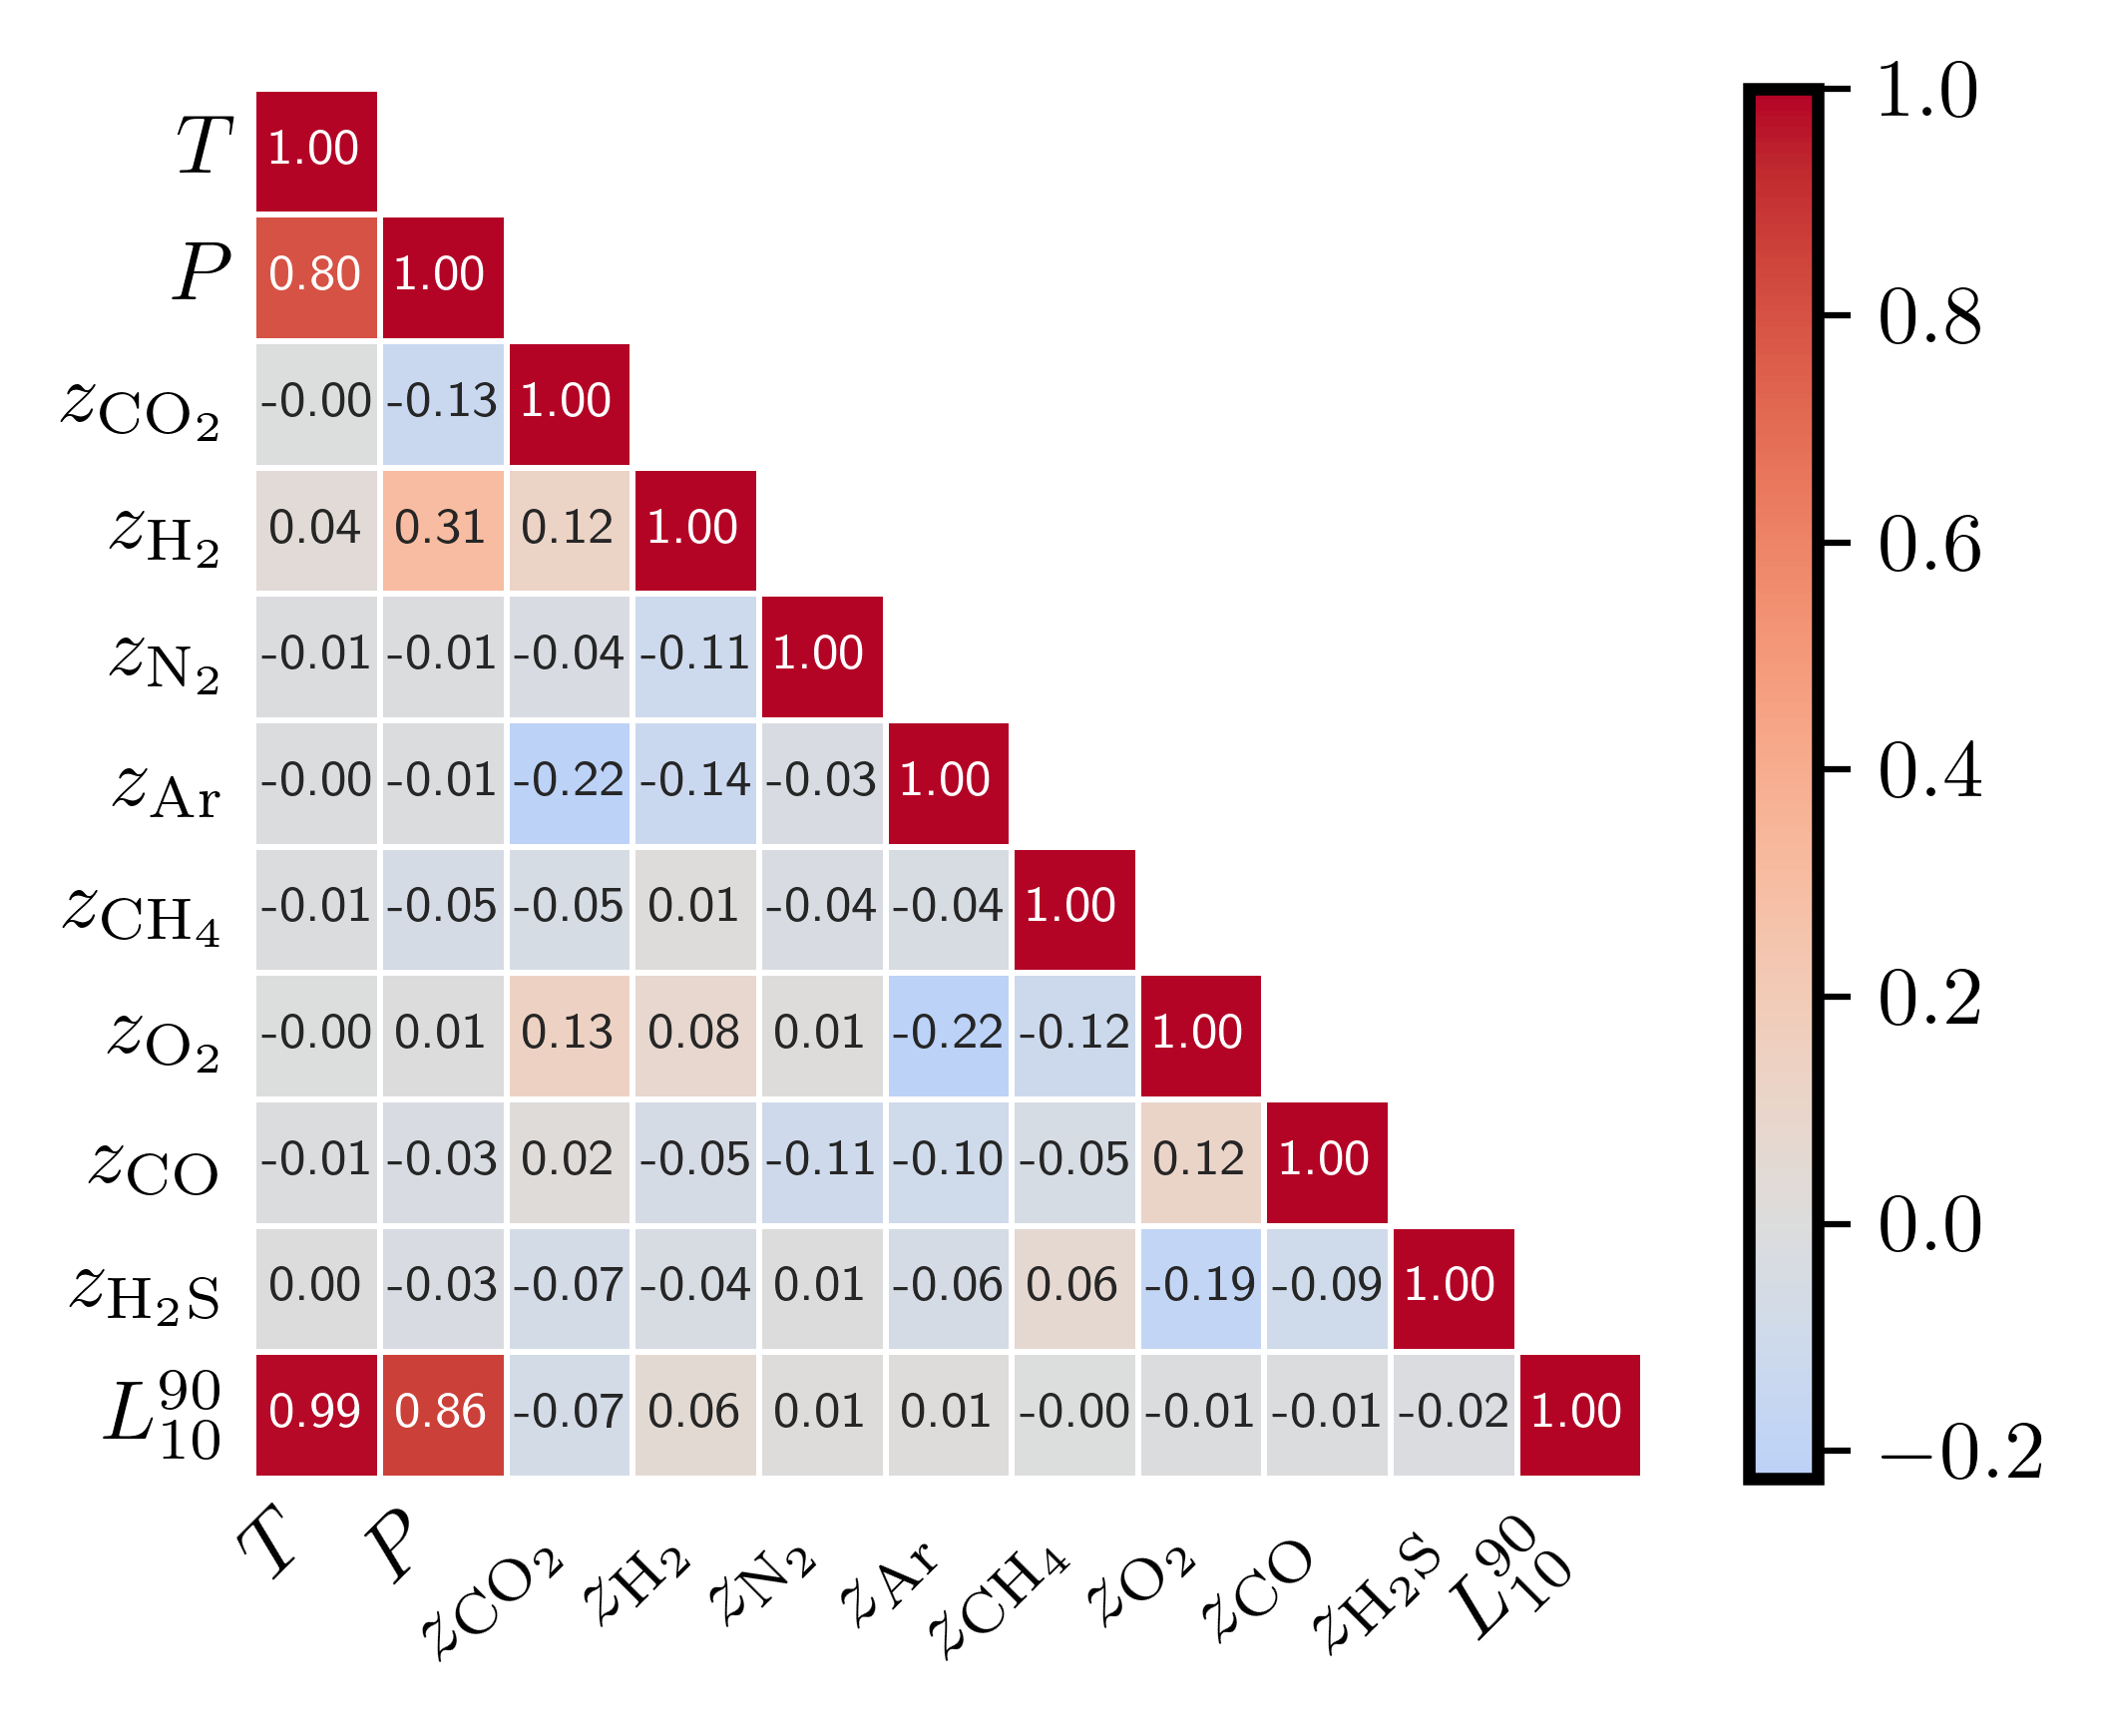

(<Figure size 2400x1800 with 2 Axes>, <Axes: >)

In [5]:
df = pd.read_csv("../../interfacial_results_dataset_A4.csv")
plot_correlation_heatmap(df, features, target, save_path=f"TabPFN_{target}_correlation", folder=PLOT_FOLDER)

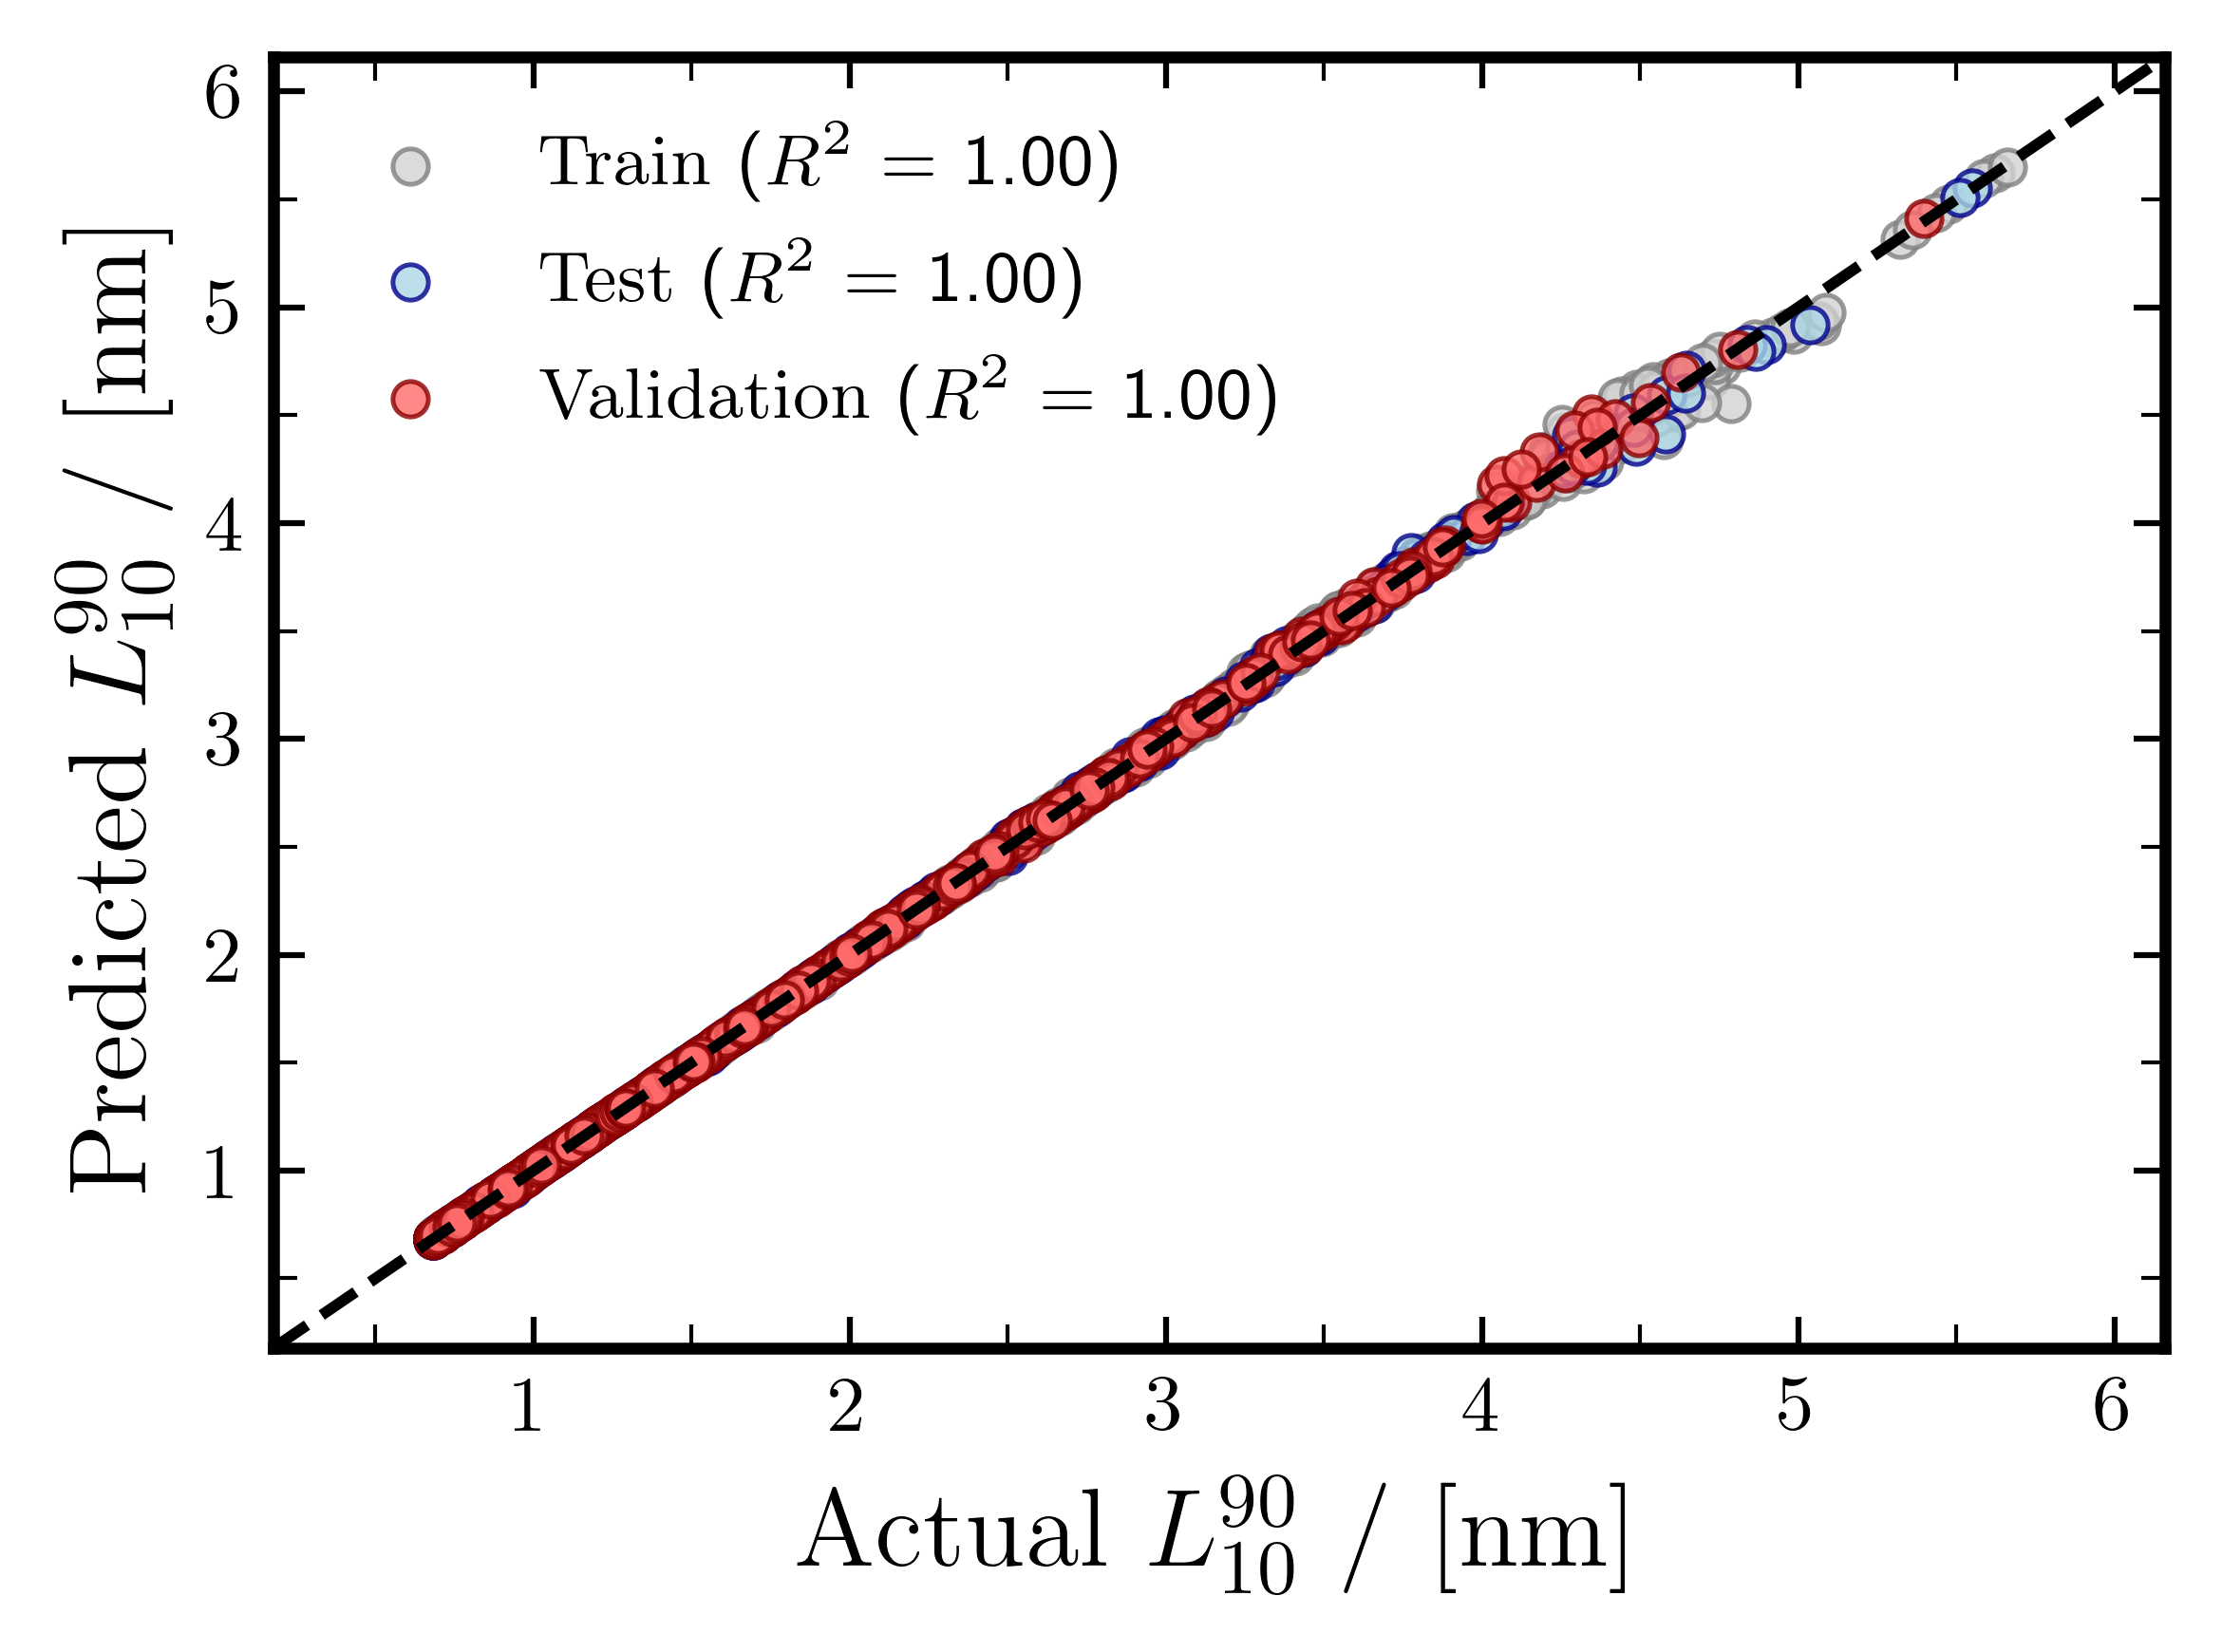

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='$\\mathrm{Actual}$ $L^{90}_{10}$ / $[\\mathrm{nm}]$', ylabel='$\\mathrm{Predicted}$ $L^{90}_{10}$ / $[\\mathrm{nm}]$'>)

In [6]:
post.plot_parity(model_name="TabPFN", save_path=f"TabPFN_{target}_parity_plot", folder=PLOT_FOLDER,
                 )

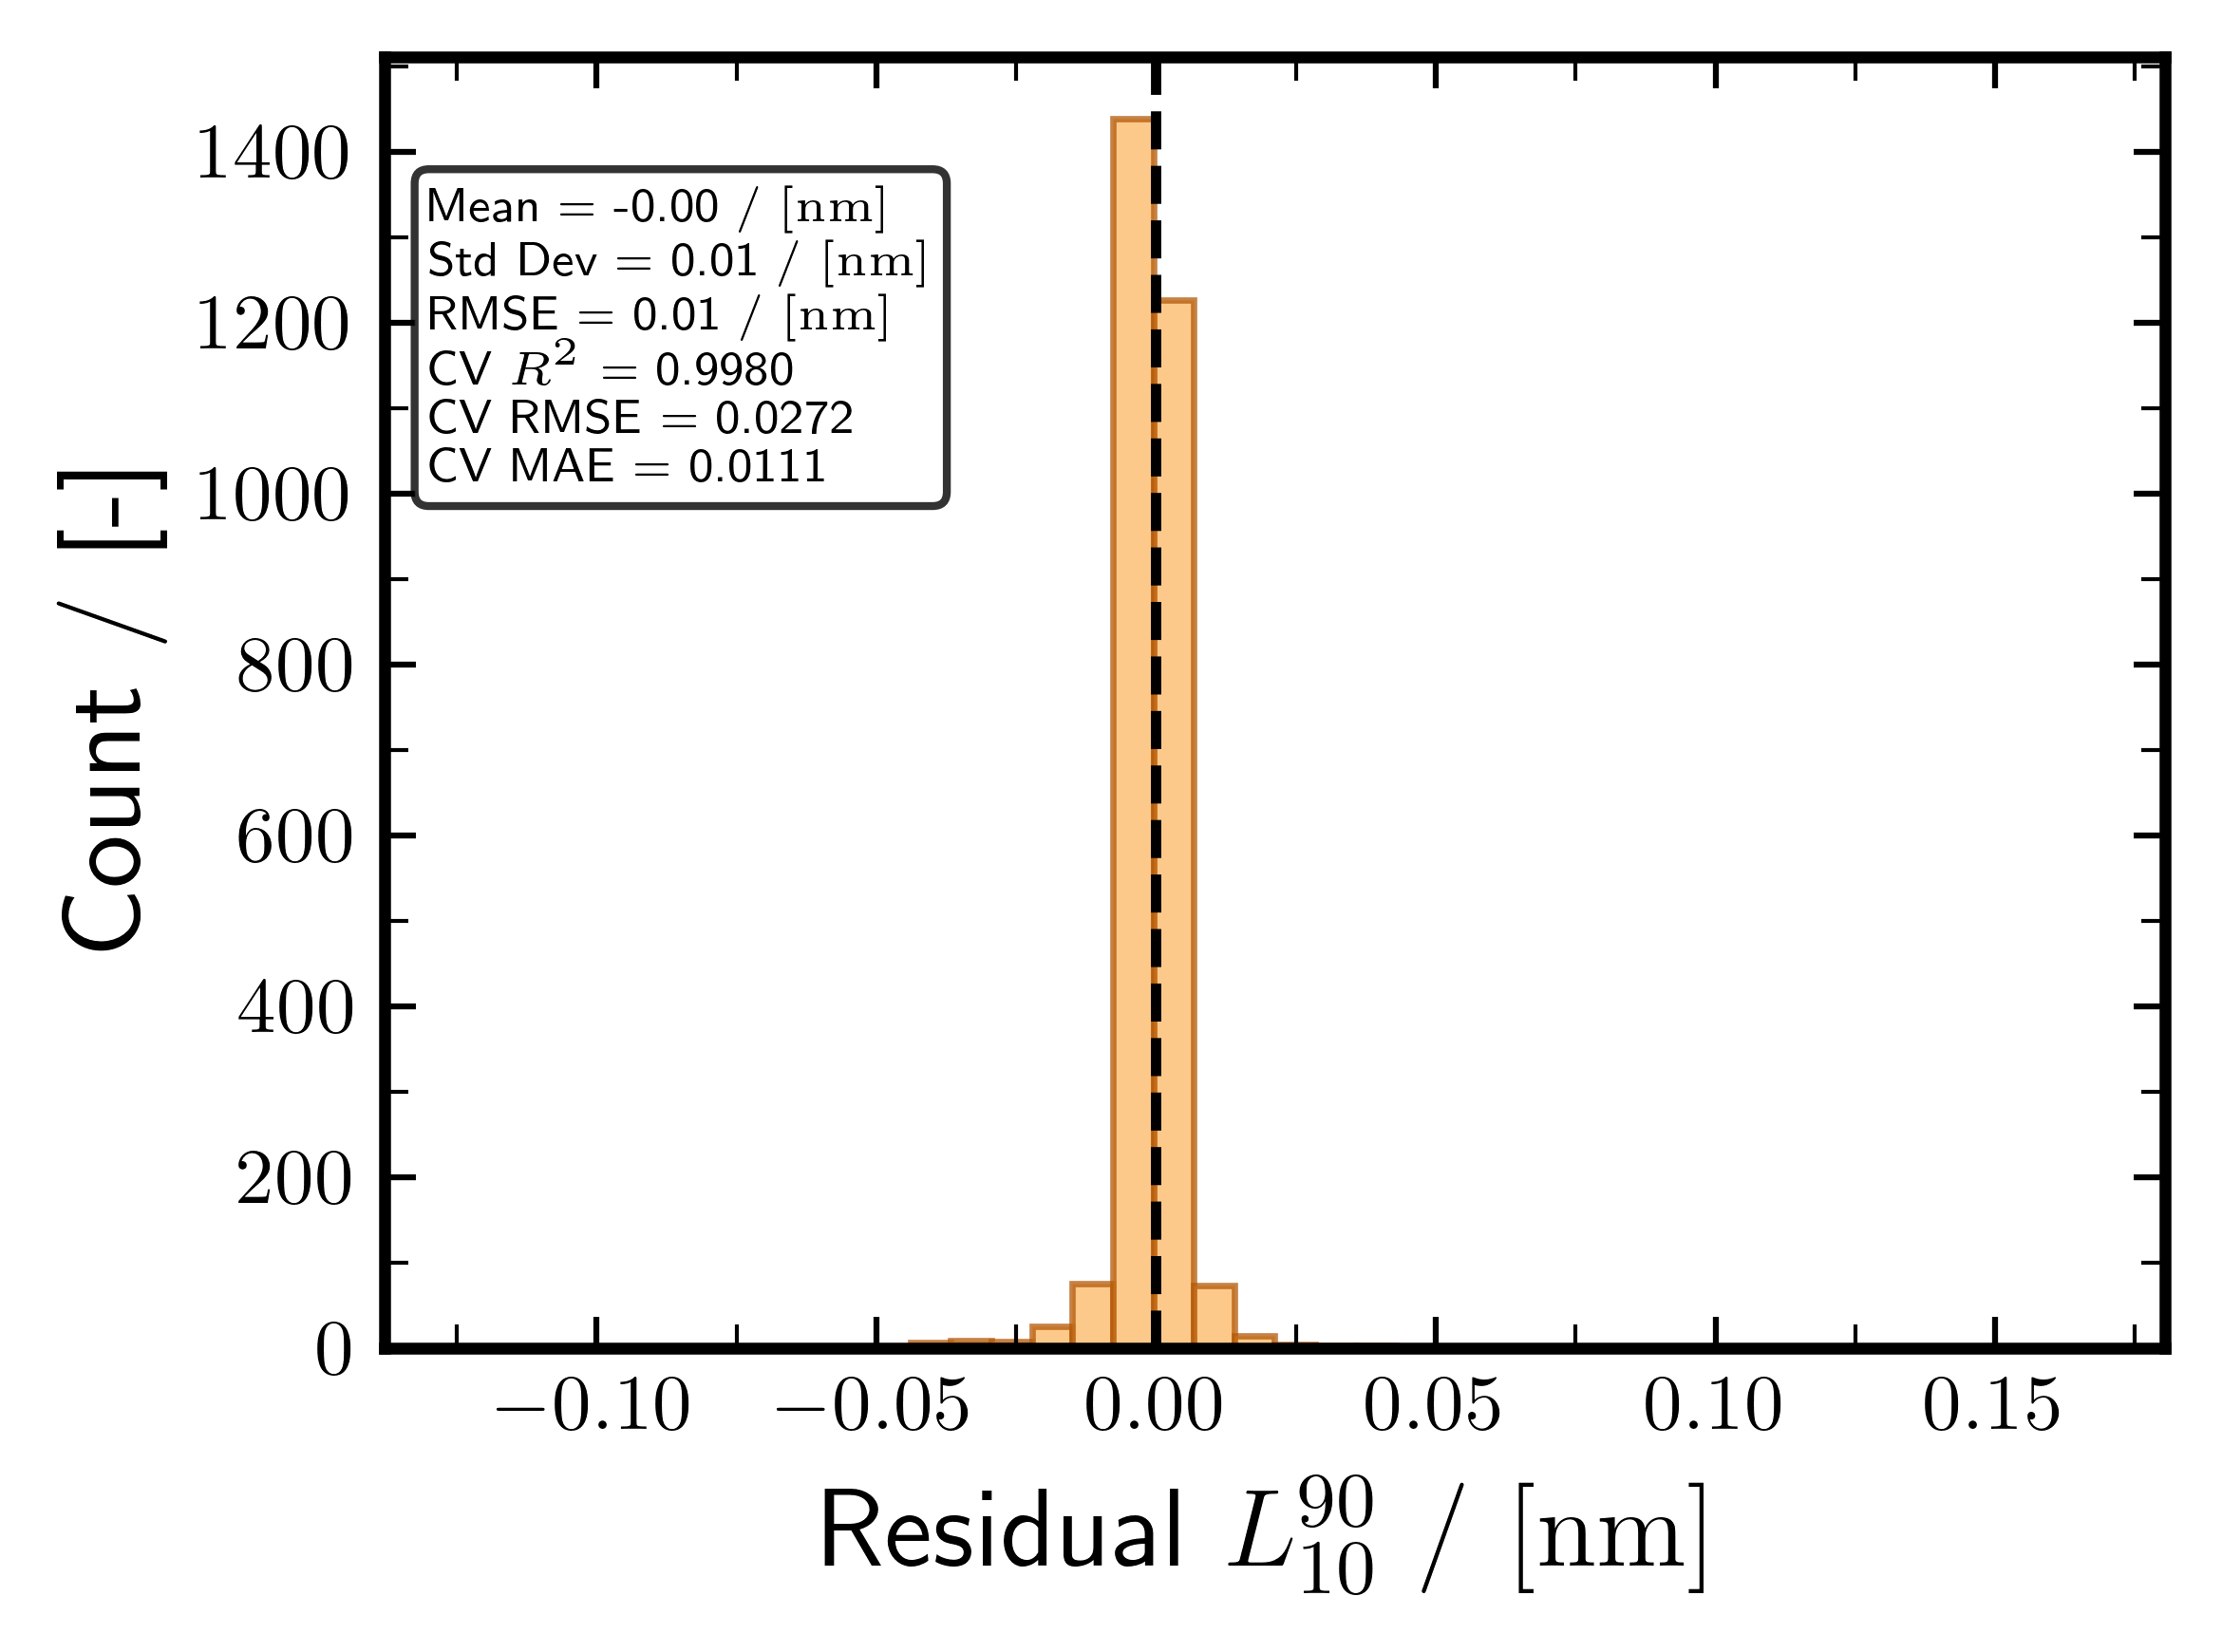

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Residual $L^{90}_{10}$ / $[\\mathrm{nm}]$', ylabel='Count / [-]'>)

In [7]:
post.plot_residual_distribution(save_path=f"TabPFN_{target}_residual_distribution", folder=PLOT_FOLDER,
                                cv_r2=cv_r2_mean, cv_rmse=cv_rmse_mean, cv_mae=cv_mae_mean)

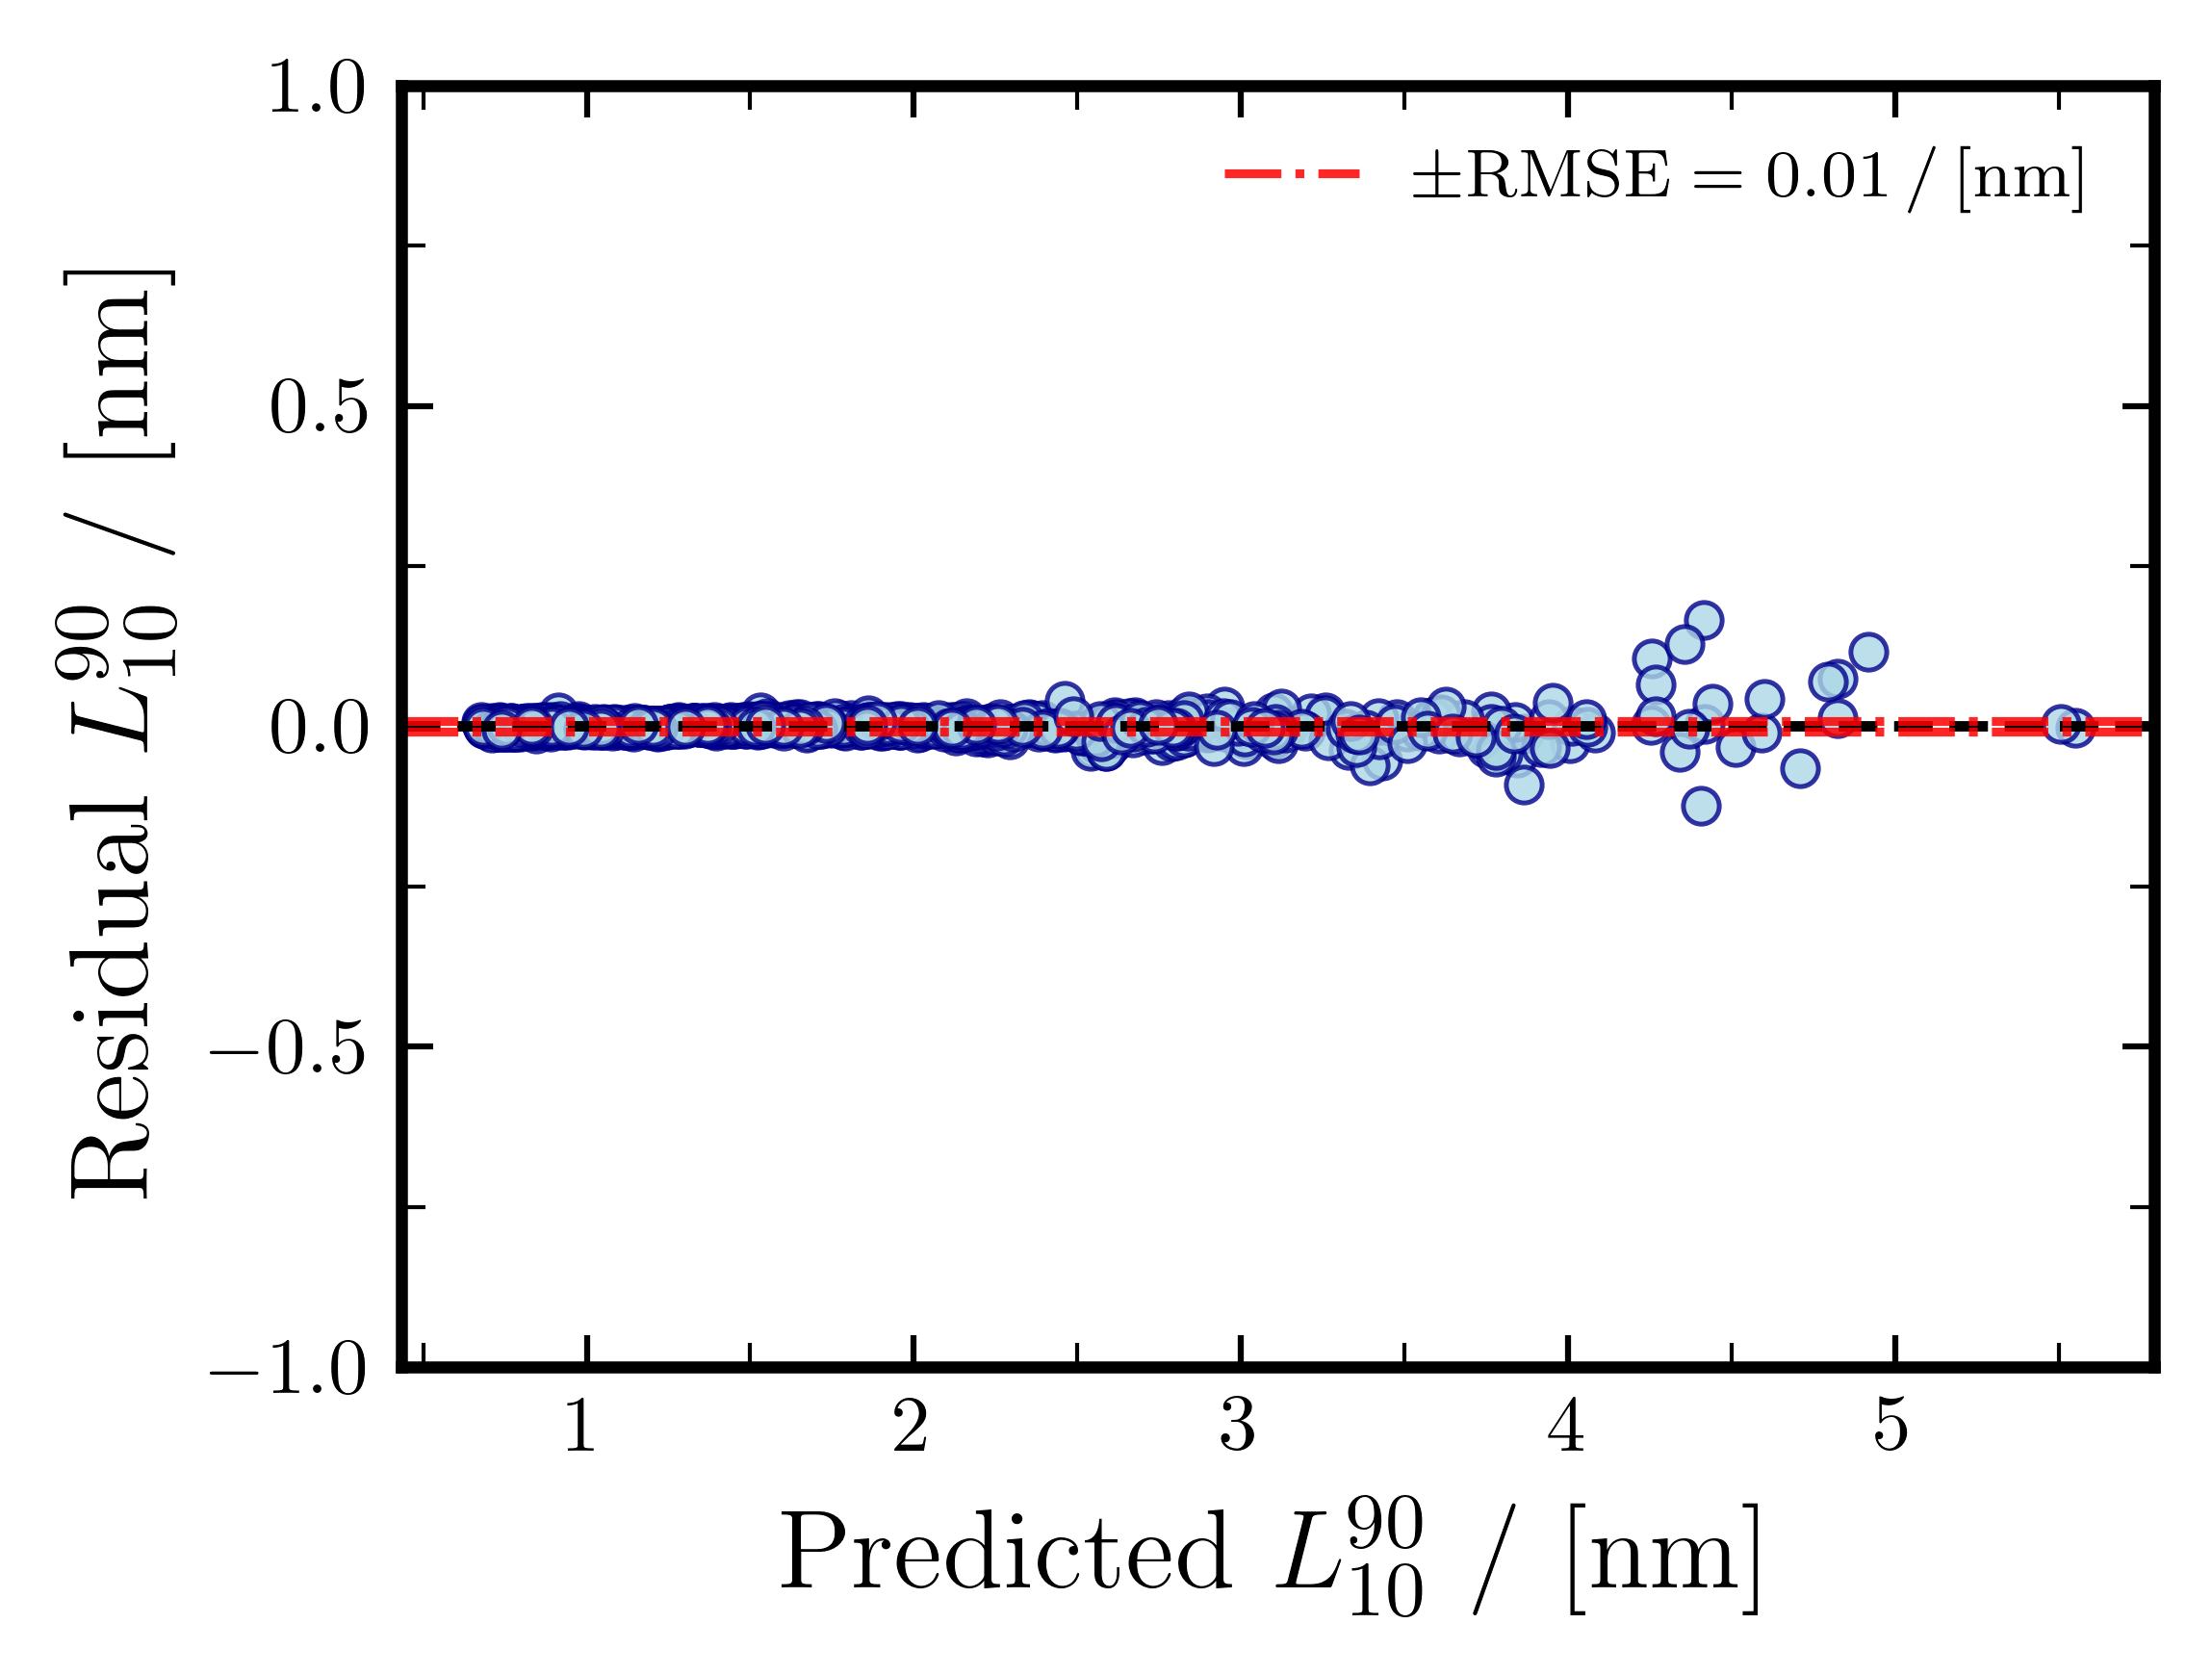

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='$\\mathrm{Predicted}$ $L^{90}_{10}$ / $[\\mathrm{nm}]$', ylabel='$\\mathrm{Residual}$ $L^{90}_{10}$ / $[\\mathrm{nm}]$'>)

In [8]:
post.plot_residual_vs_predicted(save_path=f"TabPFN_{target}_residual_vs_predicted", folder=PLOT_FOLDER,
                                y_range=[-1,1])

In [9]:
post.print_summary()

MODEL PERFORMANCE SUMMARY - INTERFACIAL_THICKNESS
Samples:        2904
R² Score:       0.999850
RMSE:           0.008434
MAE:            0.003614
Mean Residual:  -0.000732
Std Residual:   0.008403
